# 집 가격 예측 2019 캐글 ML 대회

## 1. 데이터 준비 + EDA

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os
from os.path import join

import pandas as pd
import numpy as np

import missingno as msno

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
import xgboost as xgb
import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns

print('import 완료')

import 완료


In [3]:
data_dir = os.path.join(os.getenv('HOME'), 'work/workplace/Data_Analysis/DA02/data')

train_data_path = join(data_dir, 'train.csv')
test_data_path = join(data_dir, 'test.csv')

train = pd.read_csv(train_data_path)
test = pd.read_csv(test_data_path)

train.head()

print("data파일 불러오기 완료")

data파일 불러오기 완료


In [4]:
train['date'] = train['date'].apply(lambda i: i[:6]).astype(int)

print('date column 형식을 int로 변환')
train.head()

date column 형식을 int로 변환


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,201410,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,201502,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2,2,201502,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
3,3,201406,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
4,4,201501,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711


In [5]:
y = train['price']
del train['price']

print(train.columns)

Index(['id', 'date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')


In [6]:
del train['id']

print('id column도 삭제')

id column도 삭제


In [7]:
test['date'] = test['date'].apply(lambda i: i[:6]).astype(int)

del test['id']

print('train data도 date를 int형으로 바꾸고 id 삭제')

train data도 date를 int형으로 바꾸고 id 삭제


In [8]:
y

0         221900.0
1         180000.0
2         510000.0
3         257500.0
4         291850.0
           ...    
15030     610685.0
15031    1007500.0
15032     360000.0
15033     400000.0
15034     325000.0
Name: price, Length: 15035, dtype: float64

## y 분포도 확인

y는 np.log1p() 함수를 통해 로그 변환을 해주고, 나중에 모델이 값을 예측한 후에 다시 np.expm1()을 활용해서 되돌리겠습니다. np.expm1()은 np.log1p()과는 반대로 각 원소 x마다 exp(x)-1의 값을 반환해 줍니다.

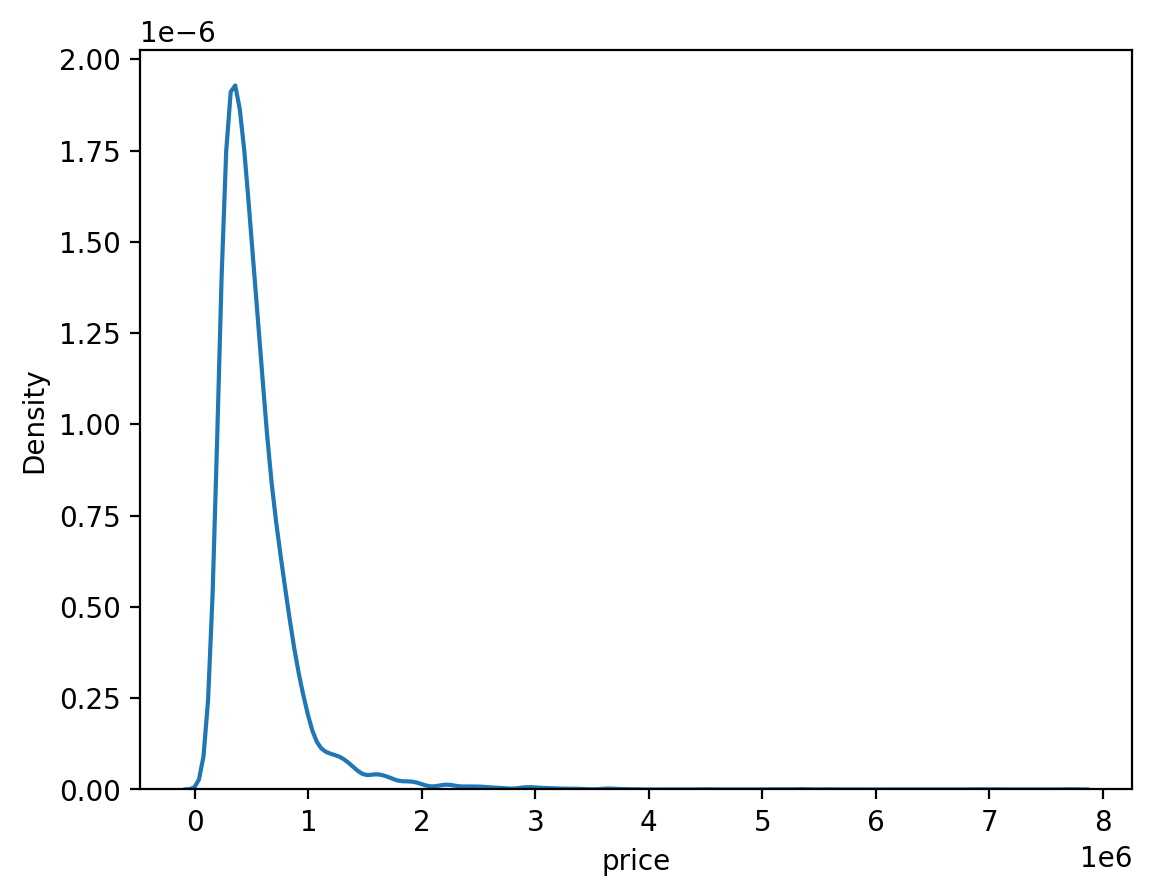

In [9]:
"""
seaborn의 `kdeplot`을 활용해 `y`의 분포를 확인해주세요!
"""

#코드 작성
sns.kdeplot(y)
plt.show()

In [10]:
y = np.log1p(y)

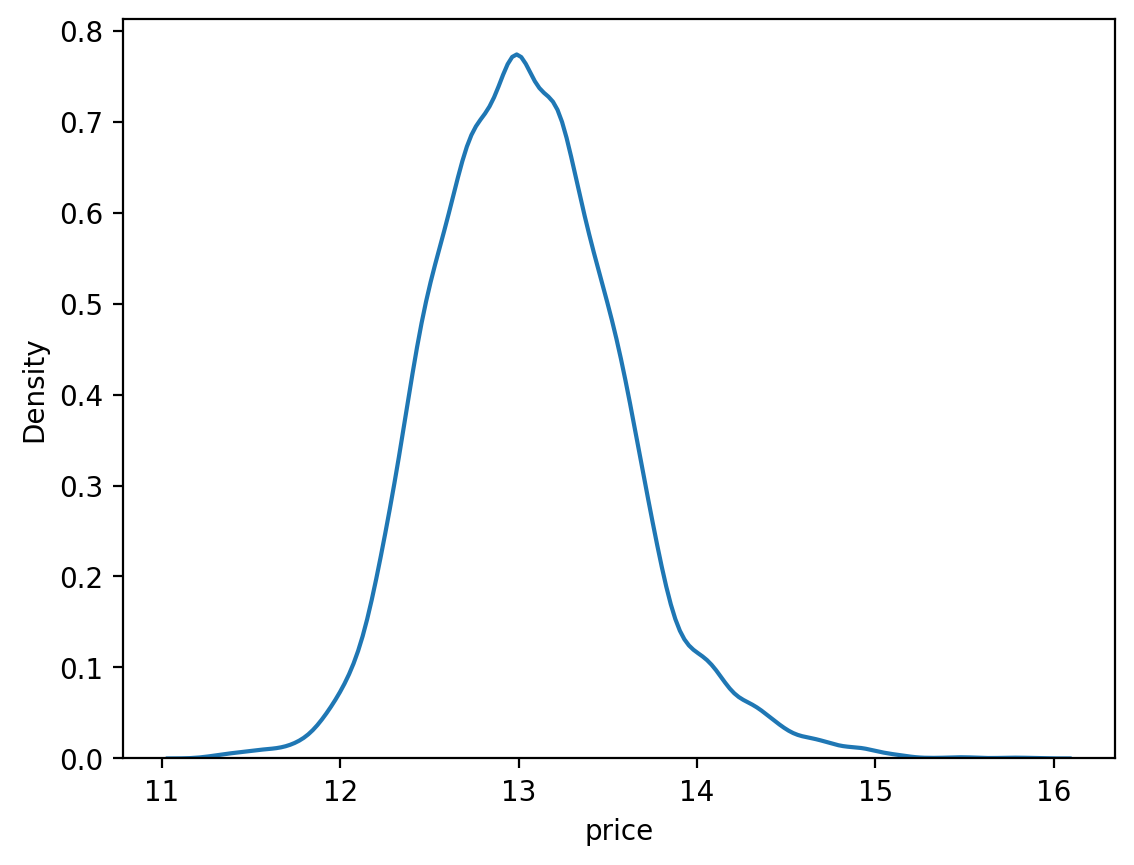

In [11]:
sns.kdeplot(y)
plt.show()

### train columns의 자료형 확인 
모두 숫자형 데이터면 모델이 학습에 사용가능

In [12]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15035 entries, 0 to 15034
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           15035 non-null  int64  
 1   bedrooms       15035 non-null  int64  
 2   bathrooms      15035 non-null  float64
 3   sqft_living    15035 non-null  int64  
 4   sqft_lot       15035 non-null  int64  
 5   floors         15035 non-null  float64
 6   waterfront     15035 non-null  int64  
 7   view           15035 non-null  int64  
 8   condition      15035 non-null  int64  
 9   grade          15035 non-null  int64  
 10  sqft_above     15035 non-null  int64  
 11  sqft_basement  15035 non-null  int64  
 12  yr_built       15035 non-null  int64  
 13  yr_renovated   15035 non-null  int64  
 14  zipcode        15035 non-null  int64  
 15  lat            15035 non-null  float64
 16  long           15035 non-null  float64
 17  sqft_living15  15035 non-null  int64  
 18  sqft_l

## 2. Preprocessing

### 전처리에 필요한 라이브러리 import 하고 재사용 가능한 변수&함수 만들기

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [15]:
def rmse(y_test, y_pred):
    return np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))

In [16]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

### 네 가지 모델 이름. models에 저장

In [17]:
random_state=2020        # 하지만 우리는 이렇게 고정값을 세팅해 두겠습니다.

gboost = GradientBoostingRegressor(random_state=random_state)
xgboost = XGBRegressor(random_state=random_state)
lightgbm = LGBMRegressor(random_state=random_state)
rdforest = RandomForestRegressor(random_state=random_state)

models = [gboost, xgboost, lightgbm, rdforest]

In [19]:
df = {}

for model in models:
    # 모델 이름 획득
    model_name = model.__class__.__name__

    # train, test 데이터셋 분리
    # random_state를 사용하여 고정하고 train과 test 셋의 비율은 8:2로 합니다.
    X_train, X_test, y_train, y_test = train_test_split(train, y, random_state=random_state, test_size=0.2)


    # 모델 학습
    model.fit(X_train, y_train)

    # 예측
    y_pred = model.predict(X_test)

    # 예측 결과의 rmse값 저장
    df[model_name] = rmse(y_test, y_pred)

    # data frame에 저장
    score_df = pd.DataFrame(df, index=['RMSE']).T.sort_values('RMSE', ascending=False)

df

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001121 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2298
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 19
[LightGBM] [Info] Start training from score 13.047779


{'GradientBoostingRegressor': np.float64(128360.19649691365),
 'XGBRegressor': np.float64(117618.22355411823),
 'LGBMRegressor': np.float64(111920.36735892233),
 'RandomForestRegressor': np.float64(125486.94461618949)}

In [20]:
def get_scores(models, train, y):
    df = {}

    for model in models:
        model_name = model.__class__.__name__

        X_train, X_test, y_train, y_test = train_test_split(train, y, random_state=random_state, test_size=0.2)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        df[model_name] = rmse(y_test, y_pred)
        score_df = pd.DataFrame(df, index=['RMSE']).T.sort_values('RMSE', ascending=False)

    return score_df

#### 그리드탐색

In [21]:
from sklearn.model_selection import GridSearchCV

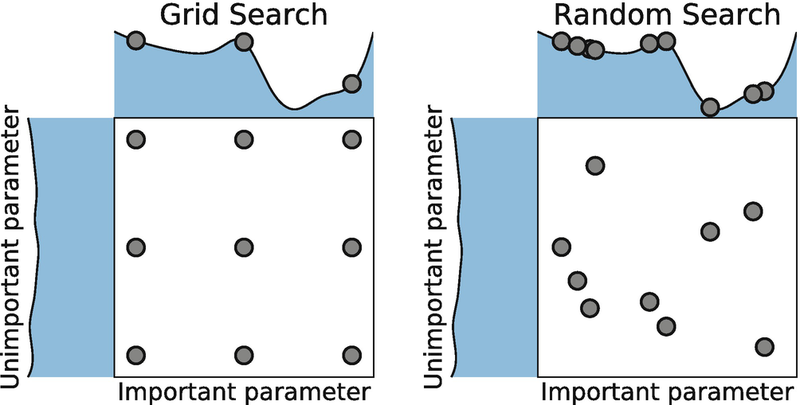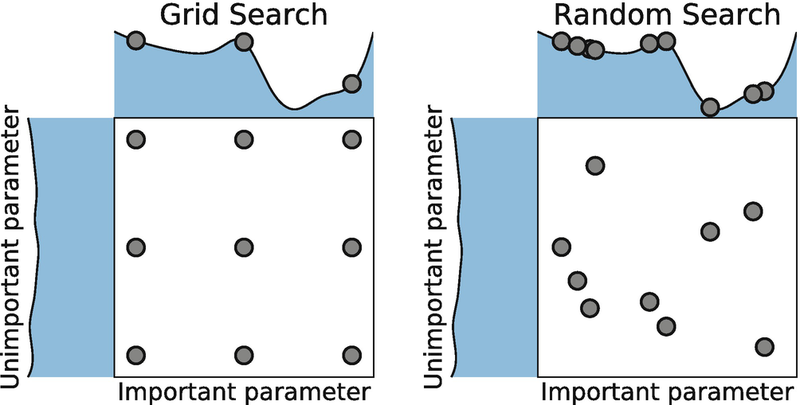

In [27]:
param_grid = {
    'n_estimators': [100, 500, 1000],  # 더 많은 나무를 시도
    'max_depth': [5, 10, 15],           # 적절한 깊이 탐색
    'learning_rate': [0.01, 0.05, 0.1] # 학습률 조절은 성능에 매우 큰 영향을 줍니다!
}



In [28]:
model = LGBMRegressor(random_state=random_state, n_estimators=100, verbosity=-1)

In [29]:
grid_model = GridSearchCV(model, param_grid=param_grid, \
                        scoring='neg_mean_squared_error', \
                        cv=5, verbose=0, n_jobs=5)

In [30]:
grid_model.fit(train, y)

GridSearchCV(cv=5, estimator=LGBMRegressor(random_state=2020, verbosity=-1),
             n_jobs=5,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [5, 10, 15],
                         'n_estimators': [100, 500, 1000]},
             scoring='neg_mean_squared_error')

#### CV 결과보기

In [31]:
grid_model.cv_results_

{'mean_fit_time': array([0.68097792, 2.56347561, 5.33450184, 0.88934207, 3.9731535 ,
        7.61364808, 0.95714946, 4.06403313, 7.16342311, 0.66821861,
        2.26633949, 4.45581889, 0.99744196, 3.07397742, 5.89660754,
        0.85758142, 3.11960163, 5.54519534, 0.58976784, 2.03484964,
        4.22360544, 0.77025805, 2.54604135, 5.11182594, 0.89652801,
        2.7848074 , 5.15916667]),
 'std_fit_time': array([0.09896536, 0.1615373 , 0.31312514, 0.10246912, 0.43413324,
        0.63013789, 0.08598759, 0.22432759, 0.23470435, 0.05117804,
        0.19293175, 0.45985322, 0.11076406, 0.36484725, 0.50316769,
        0.13587441, 0.43528246, 0.30930185, 0.04434723, 0.26954629,
        0.31416504, 0.03109758, 0.17402605, 0.23269878, 0.03916024,
        0.21515706, 0.3356191 ]),
 'mean_score_time': array([0.06015191, 0.3867157 , 1.04971294, 0.06149979, 0.38443656,
        1.20373654, 0.05691795, 0.43481007, 1.07830458, 0.05526977,
        0.39491463, 0.86642318, 0.06147017, 0.37855163, 1.220676

### 1번째 GridSearchCV 결과
지금 가장 좋은 성적이 learning_rate: 0.05, max_depth: 10, n_estimators: 500 근처에서 나왔습니다. 그렇다면 다음 번 테스트에서는 범위를 어떻게 좁혀보는 게 좋을까요?

예를 들어, learning_rate를 0.05를 중심으로 더 세밀하게(0.03, 0.05, 0.07) 확인해 볼 수도 있고, max_depth를 8, 10, 12 정도로 좁혀볼 수도 있습니다.